In [1]:
from src.utils import get_data_env
from src.UPDATED_dataloading import EpiConfig, DataOrchestrator, ShallowDataLoaderManager, GraphDataLoaderManager
from src.UPDATED_models import NodeRFModel, PersistenceModel, GATv2Model

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2002-01-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 2
horizon_leadtime= 2
sequence_length = 1
lags            = 4

config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lags                = lags,
    nuts_level          = nuts_level,
    log_transform       = True,
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    verbose             = False
    )    

epidata_loader_basis = DataOrchestrator(config).build()
shallowdata          = ShallowDataLoaderManager(epidata_loader_basis).construct_dataloaders()
# graphdata            = GraphDataLoaderManager(epidata_loader_basis).retrieve_graph('identity_graph').construct_dataloaders()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Dataloader object created for horizon_0
✓ Dataloader object created for horizon_1


<Axes: xlabel='timestamp', ylabel='incidence_lag0'>

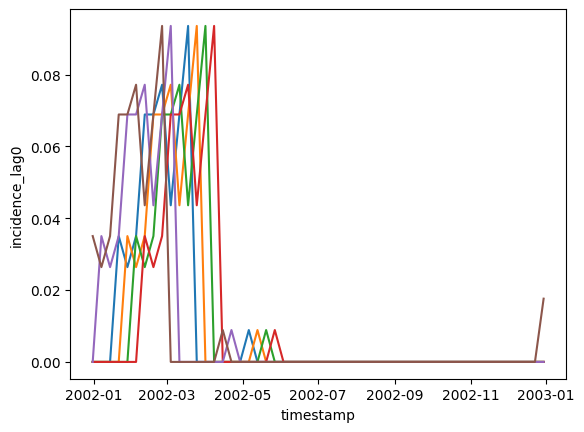

In [2]:
x = epidata_loader_basis.finalized_data.data

import pandas as pd

x = x[x['timestamp']<pd.to_datetime('2003-01-01')]

import seaborn as sns

sns.lineplot(x[x['node'] == 26], x = 'timestamp', y ='incidence_lag0')
sns.lineplot(x[x['node'] == 26], x = 'timestamp', y ='incidence_lag1')
sns.lineplot(x[x['node'] == 26], x = 'timestamp', y ='incidence_lag2')
sns.lineplot(x[x['node'] == 26], x = 'timestamp', y ='incidence_lag3')
sns.lineplot(x[x['node'] == 26], x = 'timestamp', y ='incidence_ahead2')
sns.lineplot(x[x['node'] == 26], x = 'timestamp', y ='incidence_ahead3')
# sns.lineplot(x[x['node'] == 26], x = 'timestamp', y ='incidence_h1')

Training loss for horizon 0: RMSE = 0.1491, MAE = 0.0548
Validation loss for horizon 0: RMSE = 0.2210, MAE = 0.1035
Training loss for horizon 1: RMSE = 0.1777, MAE = 0.0679
Validation loss for horizon 1: RMSE = 0.2769, MAE = 0.1296
Loss on test for horizon 0: RMSE = 0.2831, MAE = 0.1355
Loss on test for horizon 1: RMSE = 0.3374, MAE = 0.1671


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Predictions node: 26'}, ylabel='incidence'>])

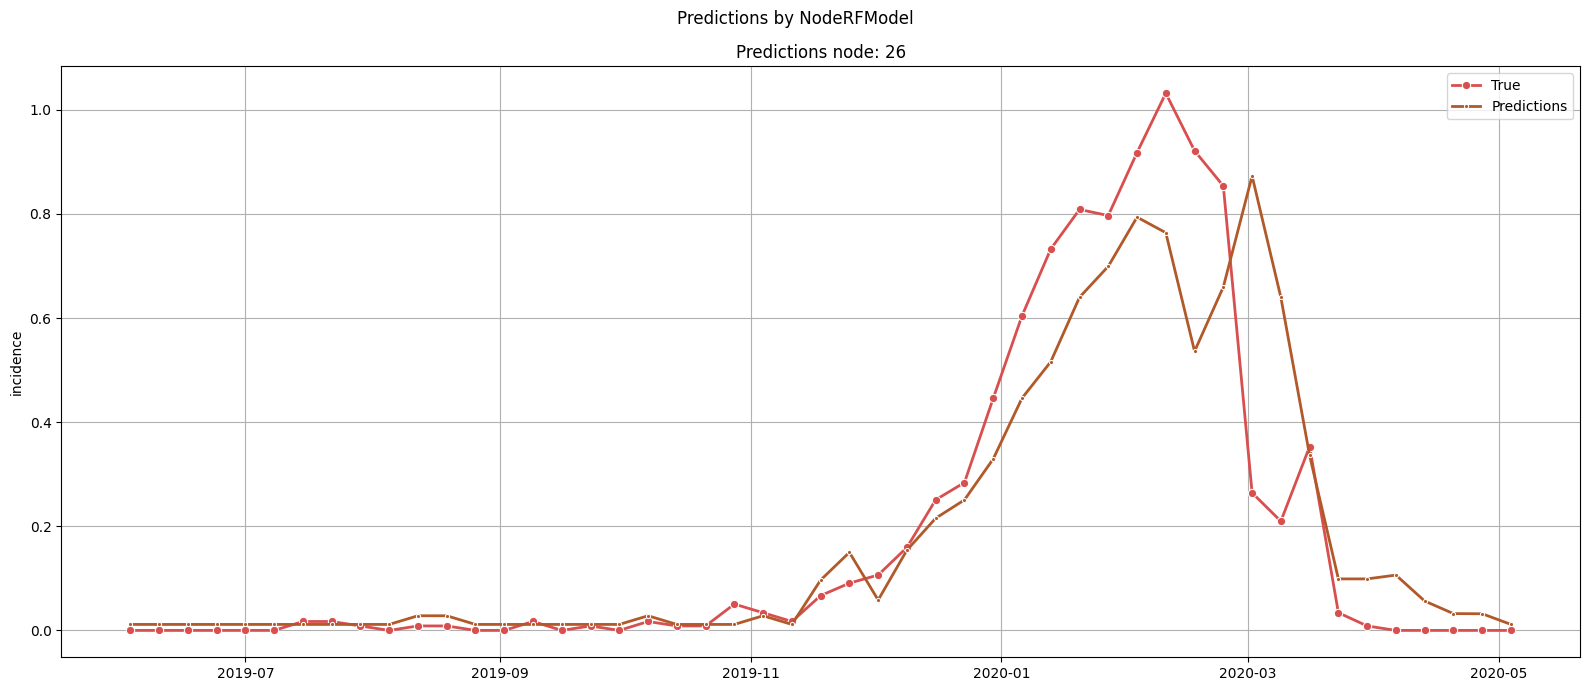

In [4]:
rf = NodeRFModel(shallowdata)
rf.set_global_hparams()
rf.set_model_hparams(n_estimators=10)
rf.train()
rf.forecast()
rf.show_forecasts(26, transformed=False, horizon=1)

ValueError: Could not interpret value `incidence` for `y`. An entry with this name does not appear in `data`.

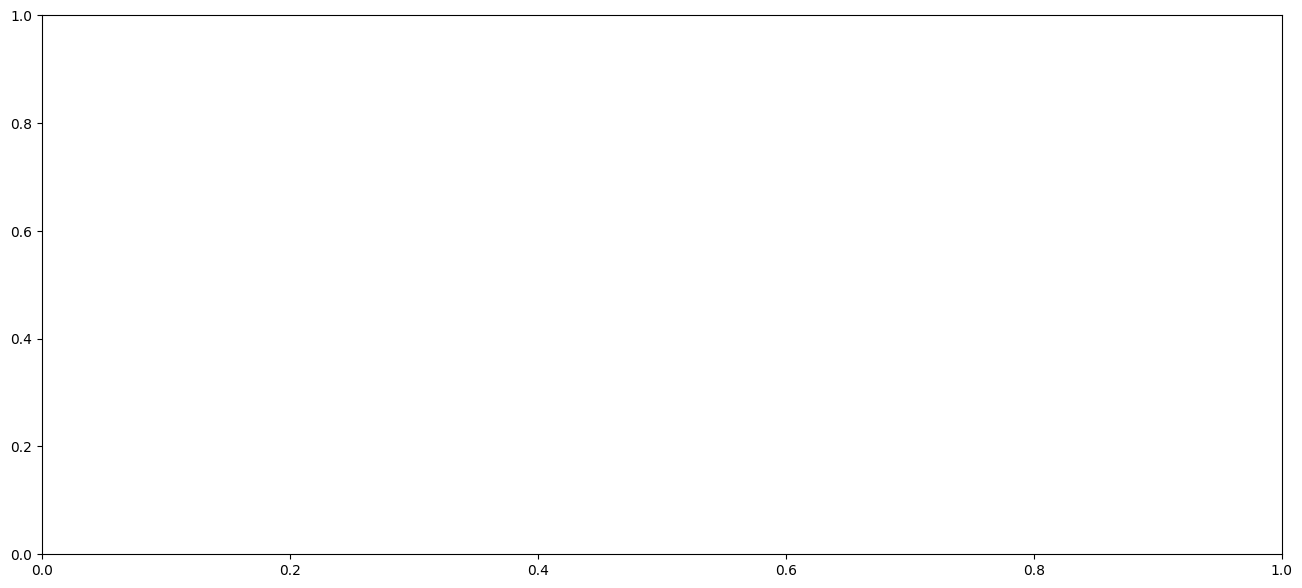

In [5]:
ps = PersistenceModel(shallowdata)
ps.forecast('test')
ps.show_forecasts(26, transformed=False)

In [9]:
shallowdata.coluomn_registration.get_transformation_groups()

{'incidence': ['incidence',
  'incidence',
  'incidence',
  'incidence_lag3',
  'incidence_lag4',
  'incidence_lag5',
  'incidence_lag6',
  'pred']}


==                    GATv2                     ==
Dataloader Snapshot: GraphData(x=(399, 3, 1), y=(399, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.7339, val loss: 1.2585 ✓ (new best)


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 568.05it/s]

Test loss: 1.5764


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Predictions node: 26'}, ylabel='incidence'>])

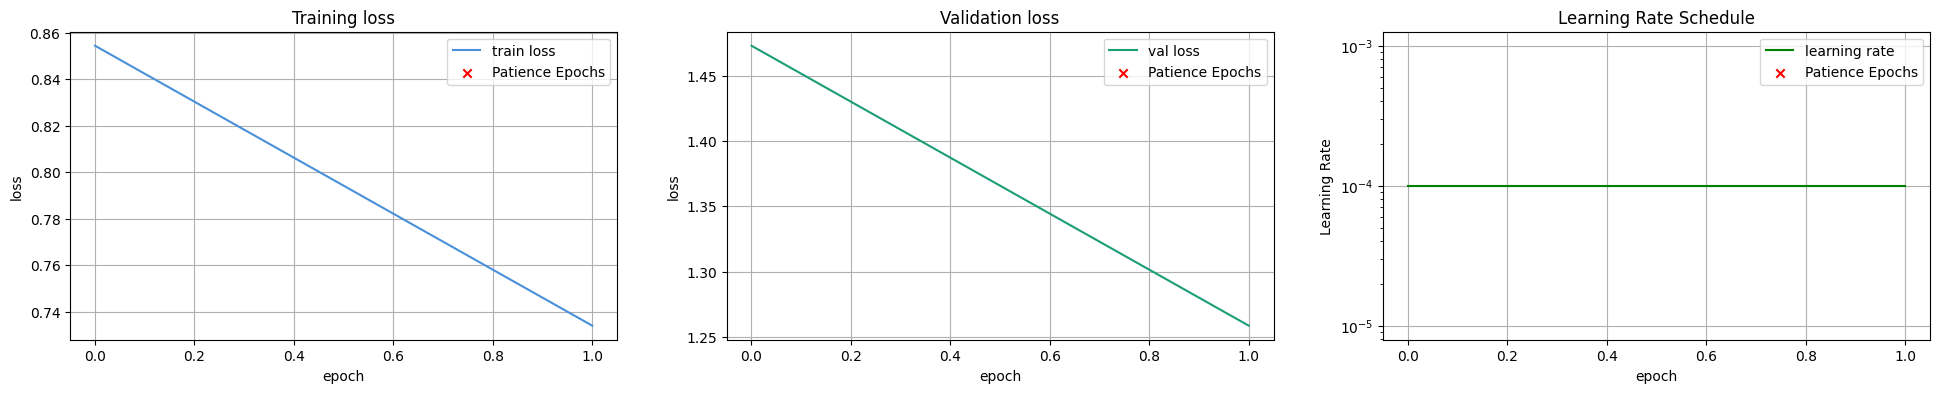

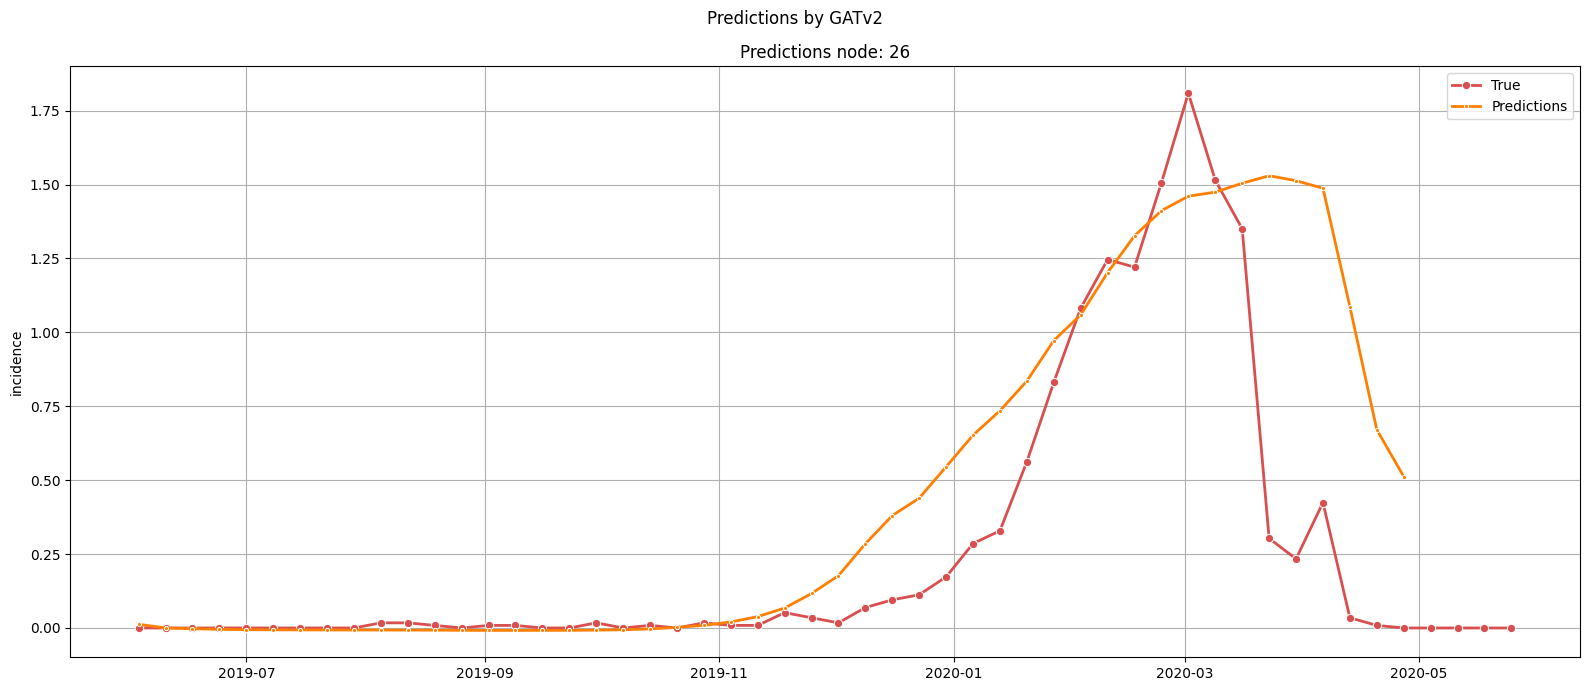

In [2]:
# training hparams
n_epochs        = 2
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

gatv2 = GATv2Model(graphdata)
gatv2.set_model_hparams()
gatv2.set_global_hparams(**global_hparams)
gatv2.train(verbose = 2)
gatv2.forecast('test')
gatv2.show_forecasts(26,'test')